Peak widths (in pixels): [11.24811899 20.22008333 22.5313357  11.96548548 30.13076302 13.75000782
  8.56809557]
Number of detected tracks: 7
Average distance between tracks (mm): 13.200


<Figure size 1500x1000 with 0 Axes>

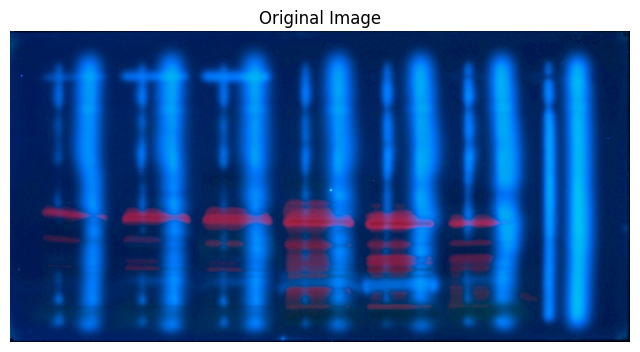

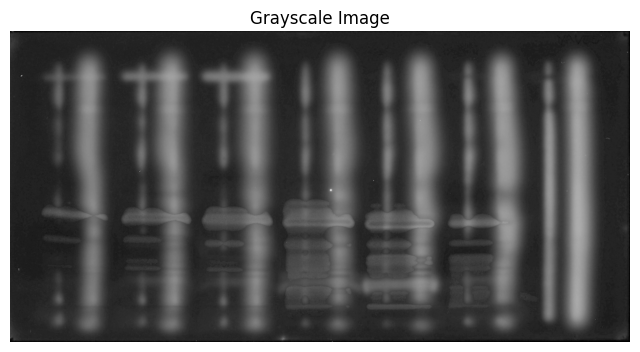

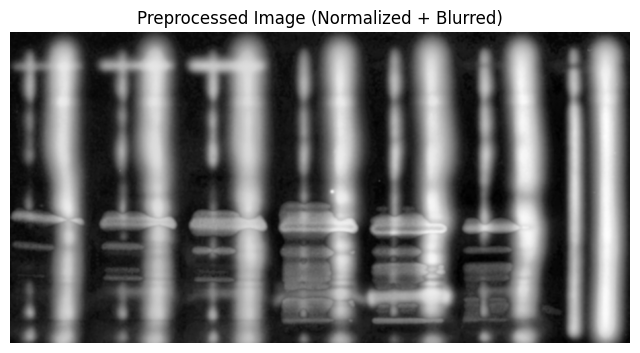

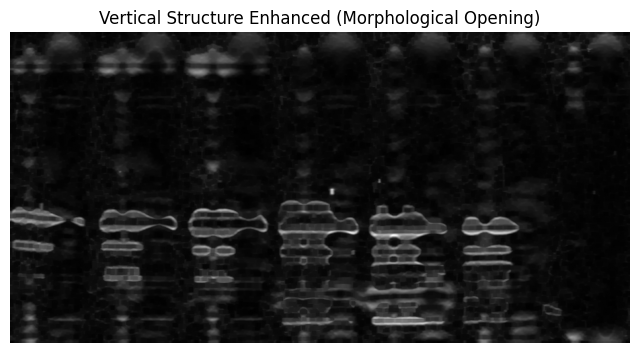

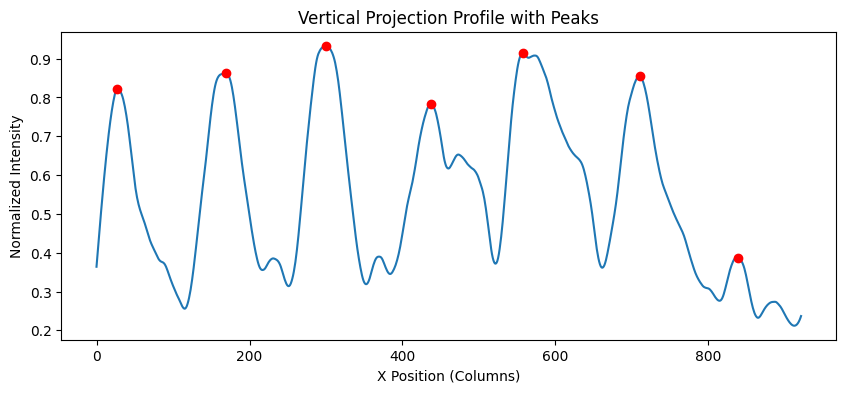

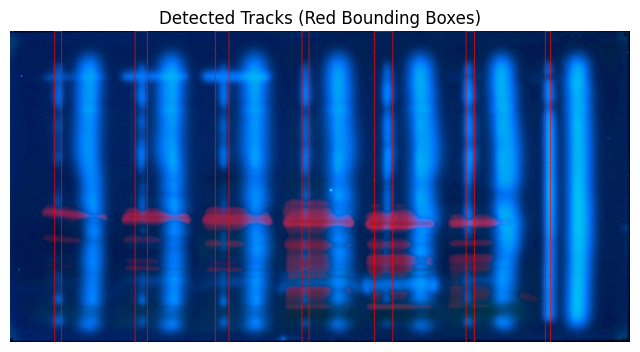

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, peak_widths, savgol_filter

# ============================
# STEP 1 — STANDARDIZE INPUT
# ============================

def preprocess_image(image_path, target_width=1024, crop_percent=0.05):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Resize
    h, w = gray.shape
    scale = target_width / w
    new_h = int(h * scale)
    resized = cv2.resize(gray, (target_width, new_h))

    # ============================
    #  Crop borders to remove noise
    # ============================
    h2, w2 = resized.shape

    crop_x = int(w2 * (crop_percent ))
    crop_y = int(h2 * crop_percent)

    cropped = resized[
        crop_y : h2 - crop_y,
        crop_x : w2 - crop_x
    ]

    # ============================
    # CLAHE (contrast enhancement)
    # ============================
    clahe = cv2.createCLAHE(
        clipLimit=3.0,
        tileGridSize=(8, 8)
    )
    equalized = clahe.apply(cropped)

    # Optional smoothing
    blurred = cv2.GaussianBlur(equalized, (5, 5), 0)

    return img, gray, blurred, scale, crop_x


# ====================================
# STEP 2 — ENHANCE VERTICAL STRUCTURES
# ====================================

# def enhance_vertical_structures(image):
#     # Invert image (important for dark tracks)
#     inverted = 255 - image

#     # Vertical kernel
#     kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 50))

#     # Opening on inverted image
#     opened = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)

#     return opened
def enhance_vertical_structures(image):

    # Invert image (helps when tracks are dark)
    inverted = 255 - image

    # Apply Sobel filter
    sobelx = cv2.Sobel(
        inverted,
        cv2.CV_64F,
        0,   # dx
        1,   # dy
        ksize=5
    )

    # Convert to absolute values
    sobelx = np.absolute(sobelx)

    # Normalize to 0–255
    sobelx = cv2.normalize(sobelx, None, 0, 255, cv2.NORM_MINMAX)

    # Convert to uint8
    sobelx = sobelx.astype(np.uint8)

    # -----------------------------
    # 🔹 Convert to binary mask
    # -----------------------------
    _, mask = cv2.threshold(
        sobelx,
        40,          # threshold value (tune this)
        255,
        cv2.THRESH_BINARY
    )

    # -----------------------------
    # 🔹 Morphological Closing
    # -----------------------------
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
    closed = cv2.morphologyEx(sobelx, cv2.MORPH_CLOSE, kernel)

    return closed

# ====================================
# STEP 3 — VERTICAL PROJECTION + PEAKS
# ====================================

def detect_tracks(enhanced_image):
    # Column-wise projection
    projection = np.sum(enhanced_image, axis=0)

    # Normalize
    projection = projection / np.max(projection)

    smoothed_projection = savgol_filter(
        projection,
        window_length=51,   # must be odd
        polyorder=3          # adjust if needed
    )



    # Now directly find peaks on inverted signal

    peaks, properties = find_peaks(
        smoothed_projection,
        # height=0.2,   # adjust if needed
        # distance=30,
        # prominence=0.1,
        prominence=0.1,           # better than height
        distance=len(projection)//20
        

    )

    results = peak_widths(smoothed_projection, peaks, rel_height=0.05)
    print("Peak widths (in pixels):", results[0])

    left_ips = results[2]
    right_ips = results[3]

    return peaks, smoothed_projection ,left_ips, right_ips




# ====================================
# STEP 4 — DRAW RED BOXES
# ====================================

# def draw_track_boxes(original_img, peaks, scale, crop_x):
#     img_copy = original_img.copy()

#     peaks_resized = peaks + crop_x
#     peaks_original = np.sort(peaks_resized / scale)

#     for i in range(len(peaks_original) - 1):

#         x1 = int(peaks_original[i])
#         x2 = int(peaks_original[i+1])

#         y1 = 0
#         y2 = img_copy.shape[0]

#         cv2.rectangle(img_copy, (x1,y1), (x2,y2), (0,0,255), 2)

#         center_x = int((x1+x2)/2)

#         cv2.putText(
#             img_copy,
#             f"B{i+1}",
#             (center_x-10,40),
#             cv2.FONT_HERSHEY_SIMPLEX,
#             0.8,
#             (0,0,255),
#             2
#         )

#     return img_copy
def draw_track_boxes(original_img, left_ips, right_ips, scale, crop_x):
    img_copy = original_img.copy()

    for left, right in zip(left_ips, right_ips):

        # Convert from cropped coordinates → original coordinates
        x1 = int((left + crop_x) / scale)
        x2 = int((right + crop_x) / scale)

        y1 = 0
        y2 = img_copy.shape[0]

        cv2.rectangle(img_copy, (x1, y1), (x2, y2), (0,0,255), 2)

    return img_copy


# ============================
# MAIN PIPELINE
# ============================

image_path = "download/3_33_2_5_2_37_3_1_1_169.tif"  # <-- replace with your image
# image_path = "Sugar.jpg"  # <-- replace with your image

original_img, gray_img, preprocessed, scale, crop_x = preprocess_image(image_path)

enhanced = enhance_vertical_structures(preprocessed)

peaks, projection, left_ips, right_ips = detect_tracks(enhanced)

result = draw_track_boxes(original_img, left_ips, right_ips, scale, crop_x)

print("Number of detected tracks:", len(peaks))

# ----------------------------
# Track spacing in millimeters
# ----------------------------
# Provide the real-world width (in mm) represented by the FULL original image width.
# Example: if the camera sees 60 mm across the full image width, set known_image_width_mm = 60.0
known_image_width_mm = 100.0  # <-- set this (float, in mm)

mm_per_pixel = None if known_image_width_mm is None else float(known_image_width_mm) / float(original_img.shape[1])

# Average distance between tracks (center-to-center)
if len(peaks) > 1 and mm_per_pixel is not None:
    peak_positions_original_px = np.sort(peaks.astype(float) / scale)
    track_distances_px = np.diff(peak_positions_original_px)
    avg_distance_mm = float(np.mean(track_distances_px) * mm_per_pixel)
    print(f"Average distance between tracks (mm): {avg_distance_mm:.3f}")
elif len(peaks) <= 1:
    print("Average distance between tracks (mm): N/A (need at least 2 tracks)")
else:
    print("Average distance between tracks (mm): N/A (set known_image_width_mm first)")


# ============================
# VISUALIZATION SECTION
# ============================

plt.figure(figsize=(15, 10))

# 1️⃣ Original Image
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")
plt.show()


# 2️⃣ Grayscale
plt.figure(figsize=(8, 6))
plt.imshow(gray_img, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()


# 3️⃣ Preprocessed (Blurred + Normalized)
plt.figure(figsize=(8, 6))
plt.imshow(preprocessed, cmap='gray')
plt.title("Preprocessed Image (Normalized + Blurred)")
plt.axis("off")
plt.show()


# 4️⃣ Enhanced Vertical Structures
plt.figure(figsize=(8, 6))
plt.imshow(enhanced, cmap='gray')
plt.title("Vertical Structure Enhanced (Morphological Opening)")
plt.axis("off")
plt.show()


# 5️⃣ Projection Profile
plt.figure(figsize=(10, 4))
plt.plot(projection)
plt.plot(peaks, projection[peaks], "ro")
plt.title("Vertical Projection Profile with Peaks")
plt.xlabel("X Position (Columns)")
plt.ylabel("Normalized Intensity")
plt.show()


# 6️⃣ Final Result with Red Boxes
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Detected Tracks (Red Bounding Boxes)")
plt.axis("off")
plt.show()

# to-do 
- run the script over all the images and extract and save bands in the each foder
- making the cluster of the bands 

In [ ]:
image_folder = "download"  # <-- replace with your image


# running over all images 

In [2]:
import os

def save_bands(original_img, left_ips, right_ips, scale, crop_x, output_dir):

    h = original_img.shape[0]

    for i, (left, right) in enumerate(zip(left_ips, right_ips)):

        # Convert to original coordinates
        x1 = int((left + crop_x) / scale)
        x2 = int((right + crop_x) / scale)

        # Safety clipping
        x1 = max(0, x1)
        x2 = min(original_img.shape[1], x2)

        # Crop band
        band = original_img[:, x1:x2]

        # Save
        band_path = os.path.join(output_dir, f"band_{i+1}.png")
        cv2.imwrite(band_path, band)

In [3]:
import os
from glob import glob

input_folder = "download"
output_root = "output_bands"

os.makedirs(output_root, exist_ok=True)

image_paths = glob(os.path.join(input_folder, "*.*"))

for image_path in image_paths:

    print(f"\nProcessing: {image_path}")

    # Get image name without extension
    image_name = os.path.splitext(os.path.basename(image_path))[0]

    # Create folder for this image
    output_dir = os.path.join(output_root, image_name)
    os.makedirs(output_dir, exist_ok=True)

    # ------------------------
    # Run your pipeline
    # ------------------------
    original_img, gray_img, preprocessed, scale, crop_x = preprocess_image(image_path)

    enhanced = enhance_vertical_structures(preprocessed)

    peaks, projection, left_ips, right_ips = detect_tracks(enhanced)

    result = draw_track_boxes(original_img, left_ips, right_ips, scale, crop_x)

    print("Number of detected tracks:", len(peaks))

    # ------------------------
    # Save bands
    # ------------------------
    save_bands(original_img, left_ips, right_ips, scale, crop_x, output_dir)

    # ------------------------
    # Save result image
    # ------------------------
    result_path = os.path.join(output_dir, "result.png")
    cv2.imwrite(result_path, result)

print("\n✅ All images processed.")


Processing: download/9_50_2_4_2_11_1_2_1_105.tif
Peak widths (in pixels): [ 7.55980354  7.64815848 11.36539484  7.95068303  5.27608474  4.60019142
  8.94577025  8.20559359  6.95752683  8.88731178  4.74073677]
Number of detected tracks: 11

Processing: download/1_21_1_5_2_33_3_1_1_192.tif
Peak widths (in pixels): [ 8.04728177 12.59895456  9.19549608  9.55426449 10.51305462 12.42606511
 10.85310182 11.89101899 14.34620844 21.33628595  8.49248801]
Number of detected tracks: 11

Processing: download/1_1_1_5_2_48_2_1_1_199.tif
Peak widths (in pixels): [15.79389563 18.06403469 11.80272543 13.00273695 16.84018001 13.70538844
 11.4203939  16.27194919 11.31299093 14.40214655  9.07416037  5.87025114]
Number of detected tracks: 12

Processing: download/1_7_1_5_2_33_3_3_1_179.tif
Peak widths (in pixels): [ 9.32263852 14.20841756  9.9447591   9.79832842 11.99342661 12.97845769
 21.49475732 14.78486936 16.88599736]
Number of detected tracks: 9

Processing: download/3_33_2_5_2_53_2_1_1_159.tif
Peak 